In [ ]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

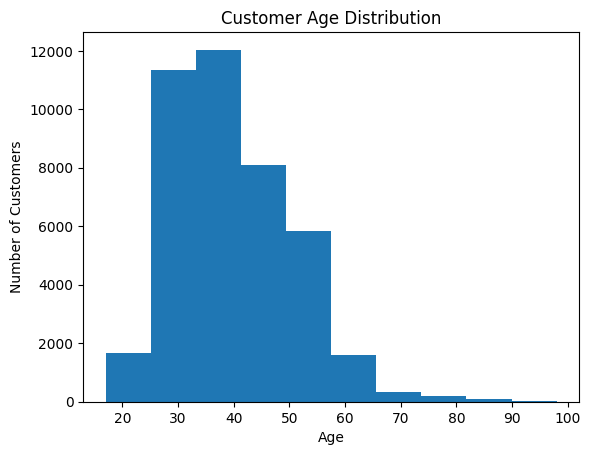

In [ ]:
# Age distribution
df = pd.read_csv("/content/data.csv")

plt.hist(df["age"].dropna(), bins=10)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")

plt.show()

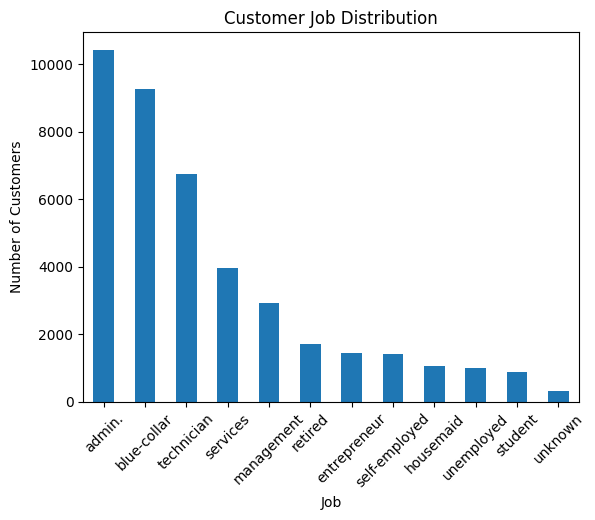

In [ ]:
job_counts = df["job"].value_counts()

job_counts.plot(kind="bar")

plt.xlabel("Job")
plt.ylabel("Number of Customers")
plt.title("Customer Job Distribution")
plt.xticks(rotation=45)

plt.show()

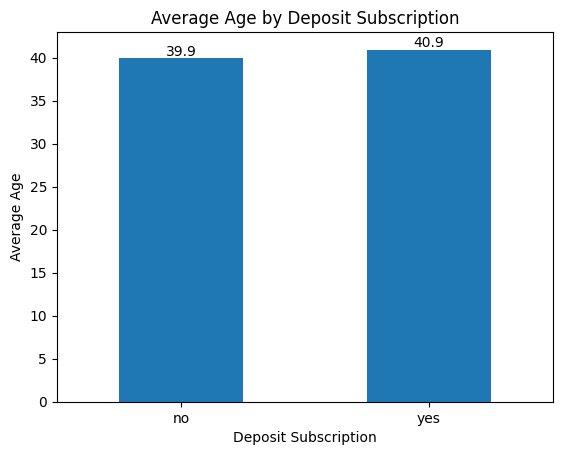

In [ ]:
avg_age = df.groupby("y")["age"].mean()

ax = avg_age.plot(kind="bar")

plt.xlabel("Deposit Subscription")
plt.ylabel("Average Age")
plt.title("Average Age by Deposit Subscription")
plt.xticks(rotation=0)

for i, value in enumerate(avg_age):
    ax.text(i, value + 0.3, f"{value:.1f}", ha="center")

plt.show()

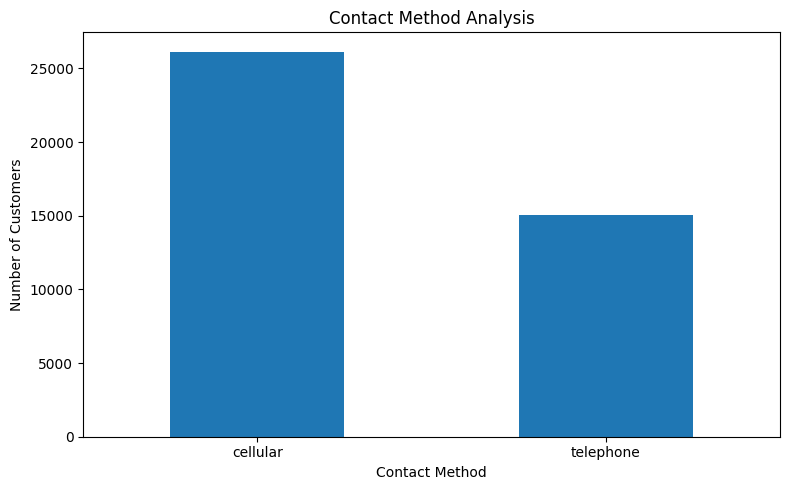

In [ ]:
contact_counts = df["contact"].value_counts()

plt.figure(figsize=(8, 5))
contact_counts.plot(kind="bar")

plt.title("Contact Method Analysis")
plt.xlabel("Contact Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

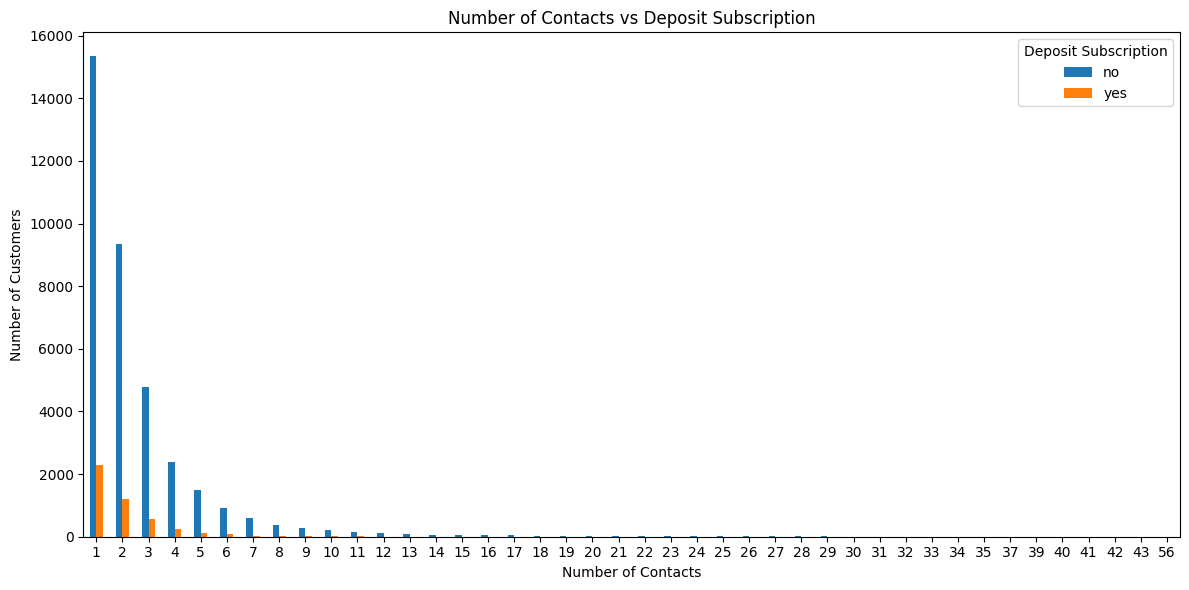

In [18]:
contact_subscription = pd.crosstab(
    df["campaign"],
    df["y"]
)

contact_subscription.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Number of Contacts vs Deposit Subscription")
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Customers")
plt.legend(title="Deposit Subscription")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

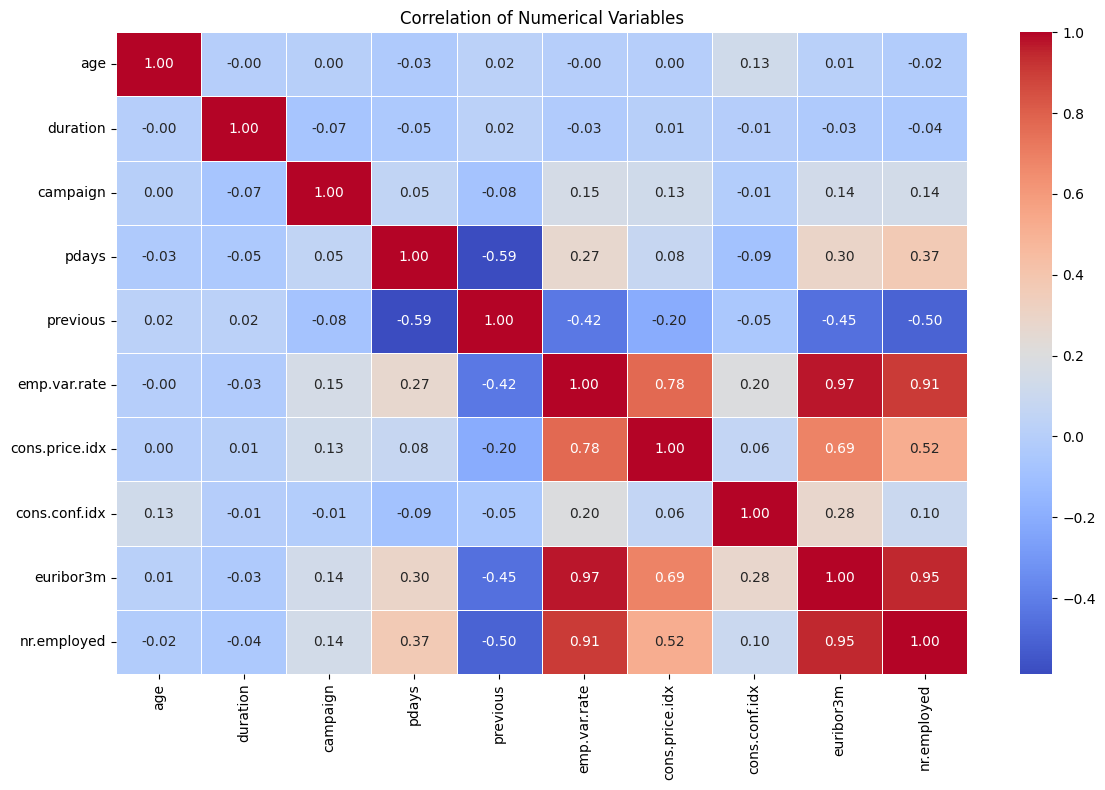

In [19]:
# Select numerical columns
numerical_data = df.select_dtypes(include="number")

# Calculate correlation
correlation = numerical_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation of Numerical Variables")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
data = df.copy()

# Encode target variable
le = LabelEncoder()
data["y"] = le.fit_transform(data["y"])

# Encode categorical columns
categorical_cols = data.select_dtypes(include=["object"]).columns

data[categorical_cols] = data[categorical_cols].apply(
    lambda col: LabelEncoder().fit_transform(col.astype(str))
)

print(data.head())

   age  job  marital  education  default  housing  loan  contact  month  \
0   56    3        1          0        0        0     0        1      6   
1   57    7        1          3        1        0     0        1      6   
2   37    7        1          3        0        2     0        1      6   
3   40    0        1          1        0        0     0        1      6   
4   56    7        1          3        0        0     2        1      6   

   day_of_week  ...  campaign  pdays  previous  poutcome  emp.var.rate  \
0            1  ...         1    999         0         1           1.1   
1            1  ...         1    999         0         1           1.1   
2            1  ...         1    999         0         1           1.1   
3            1  ...         1    999         0         1           1.1   
4            1  ...         1    999         0         1           1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  
0          93.994          -36.4      4.85

In [21]:
X = data.drop("y", axis=1)
y = data["y"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9136926438455936

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.70      0.41      0.52       928

    accuracy                           0.91      8238
   macro avg       0.81      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238



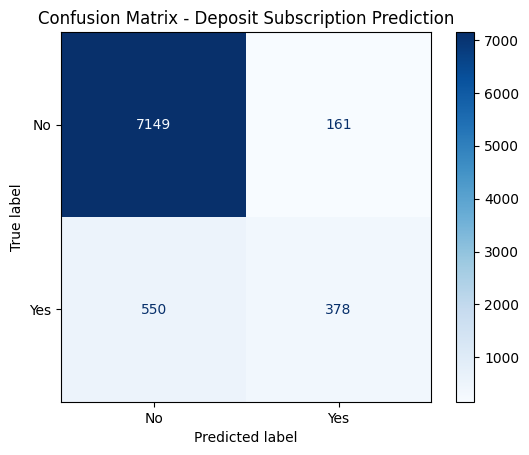

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No", "Yes"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Deposit Subscription Prediction")
plt.show()

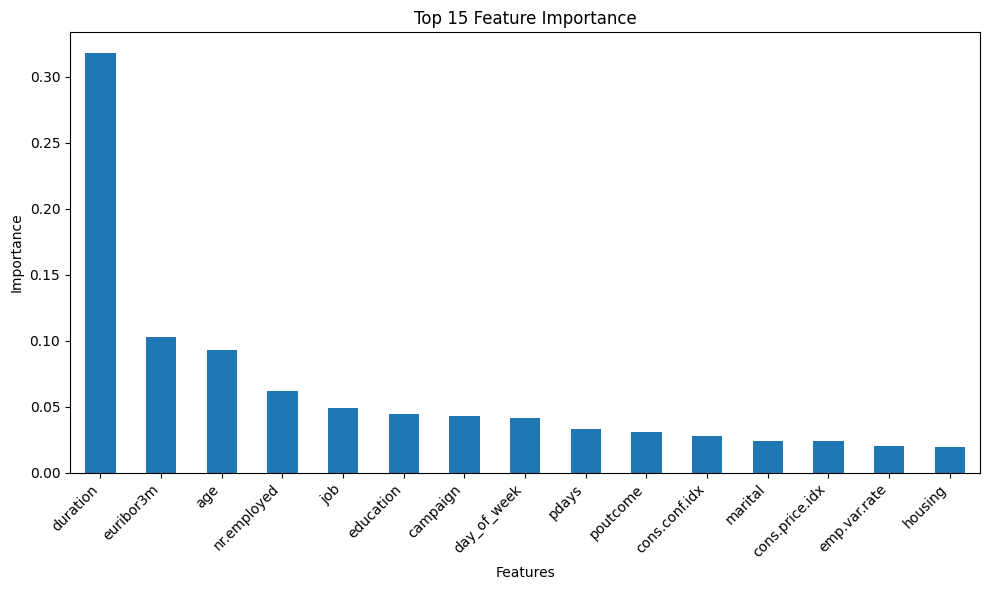

In [28]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
importance.head(15).plot(kind="bar")

plt.title("Top 15 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()